# FM5 phasemeter spectra

Plot the spectrum of **each FM5 file separately** using `scipy.signal.welch`
with a **linear frequency axis**.

For every acquisition the differential interferometer phase `ch1 - ch2`
(in cycles) is formed, converted to radians, and its one-sided amplitude
spectral density (ASD) is estimated with Welch's method and shown in its own
figure. The modulation tone (100 Hz throughout the FM5 campaign) is marked for
reference.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

from mokutools.phasemeter import MokuPhasemeterObject

# --- Configuration -----------------------------------------------------------
# Directory holding the FM5 acquisitions (.zip / .csv). Adjust if needed.
_candidates = ["data/FM5", "../data/FM5"]
FM5_DIR = next((p for p in _candidates if os.path.isdir(p)), "FM5")

# Welch settings.
SEGMENT_SECONDS = 60.0      # segment length -> frequency resolution ~ 1/SEGMENT_SECONDS
OVERLAP_FRACTION = 0.5
FMAX = None                 # upper limit of the (linear) frequency axis [Hz]; None = Nyquist

# FM5 was modulated at 100 Hz for every acquisition.
MOD_FREQ = 100.0

# One file per acquisition: prefer the .zip when both .zip and .csv exist.
paths = {}
for p in sorted(glob.glob(os.path.join(FM5_DIR, "*.zip")) +
                glob.glob(os.path.join(FM5_DIR, "*.csv"))):
    stem = os.path.splitext(os.path.basename(p))[0]
    if stem not in paths or p.lower().endswith(".zip"):
        paths[stem] = p
files = [paths[s] for s in sorted(paths)]
print(f"Found {len(files)} acquisitions in {FM5_DIR}")


Found 26 acquisitions in ../data/FM5


In [2]:
def differential_phase(obj):
    """Differential interferometer phase ch1 - ch2 [cycles], DC removed.

    Falls back to the single available channel if only one is present.
    """
    if obj.nchan >= 2:
        phi = obj.df["1_cycles"].to_numpy() - obj.df["2_cycles"].to_numpy()
        label = "ch1 - ch2"
    else:
        phi = obj.df["1_cycles"].to_numpy()
        label = "ch1"
    return phi - np.mean(phi), label


def welch_asd(phi_cycles, fs):
    """One-sided amplitude spectral density [rad/sqrt(Hz)] via scipy.welch."""
    phi = phi_cycles * (2 * np.pi)  # cycles -> radians
    nperseg = int(SEGMENT_SECONDS * fs)
    noverlap = int(OVERLAP_FRACTION * nperseg)
    f, psd = welch(phi, fs=fs, nperseg=nperseg, noverlap=noverlap,
                   detrend="constant")
    return f, np.sqrt(psd)


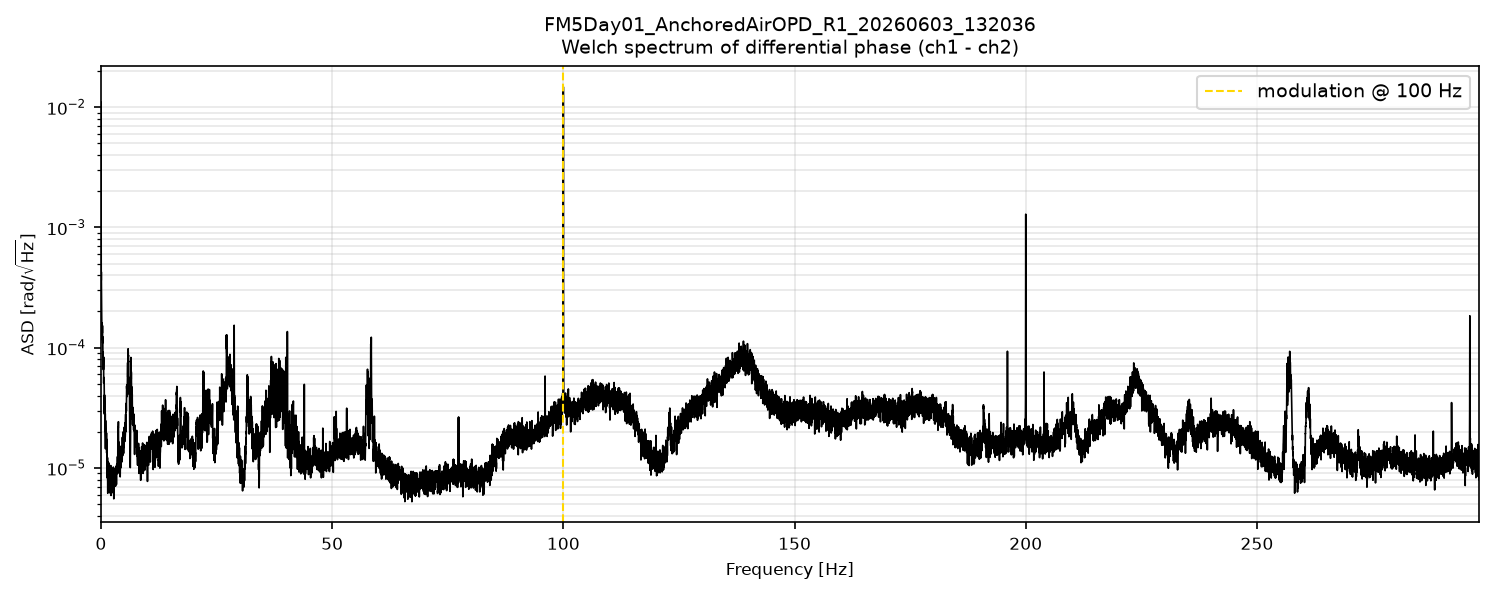

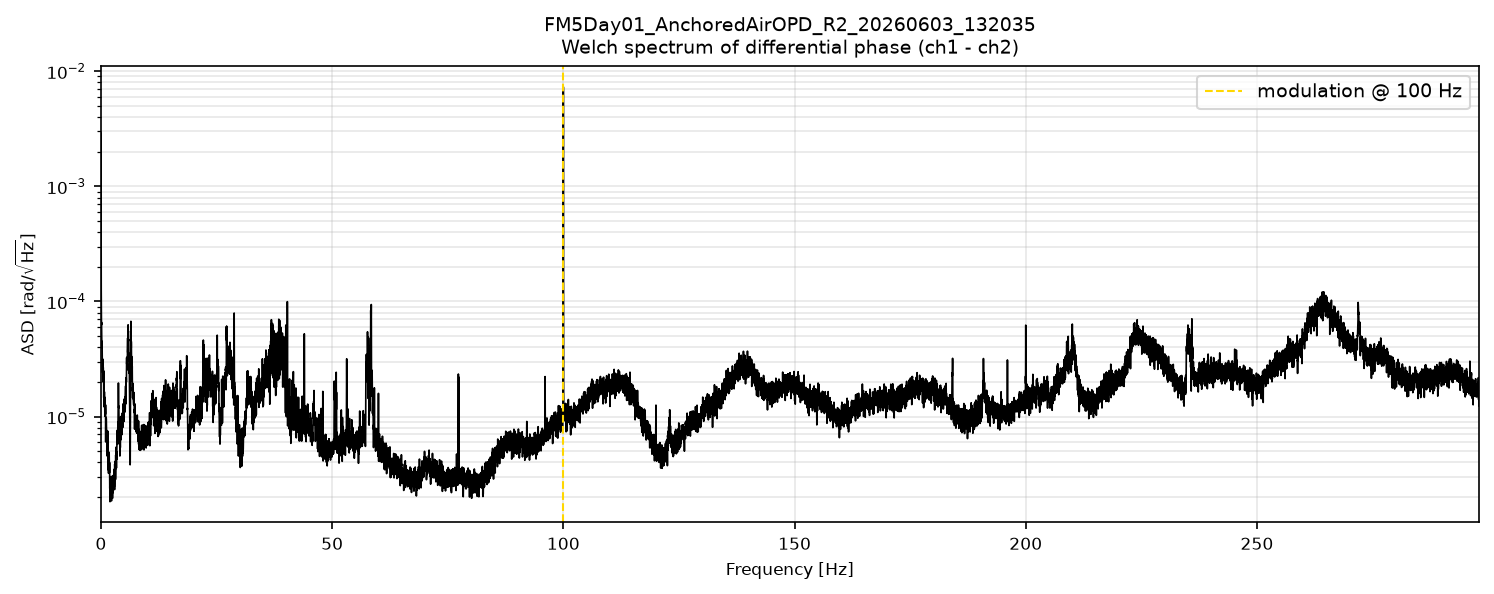

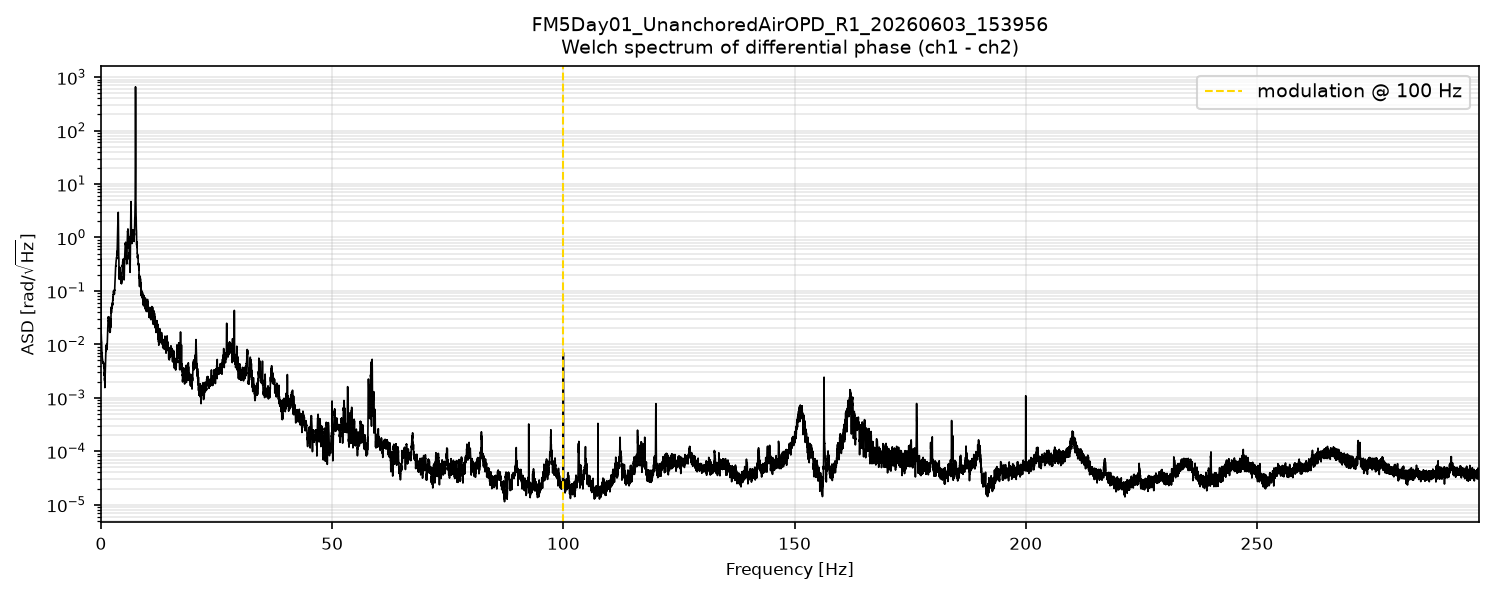

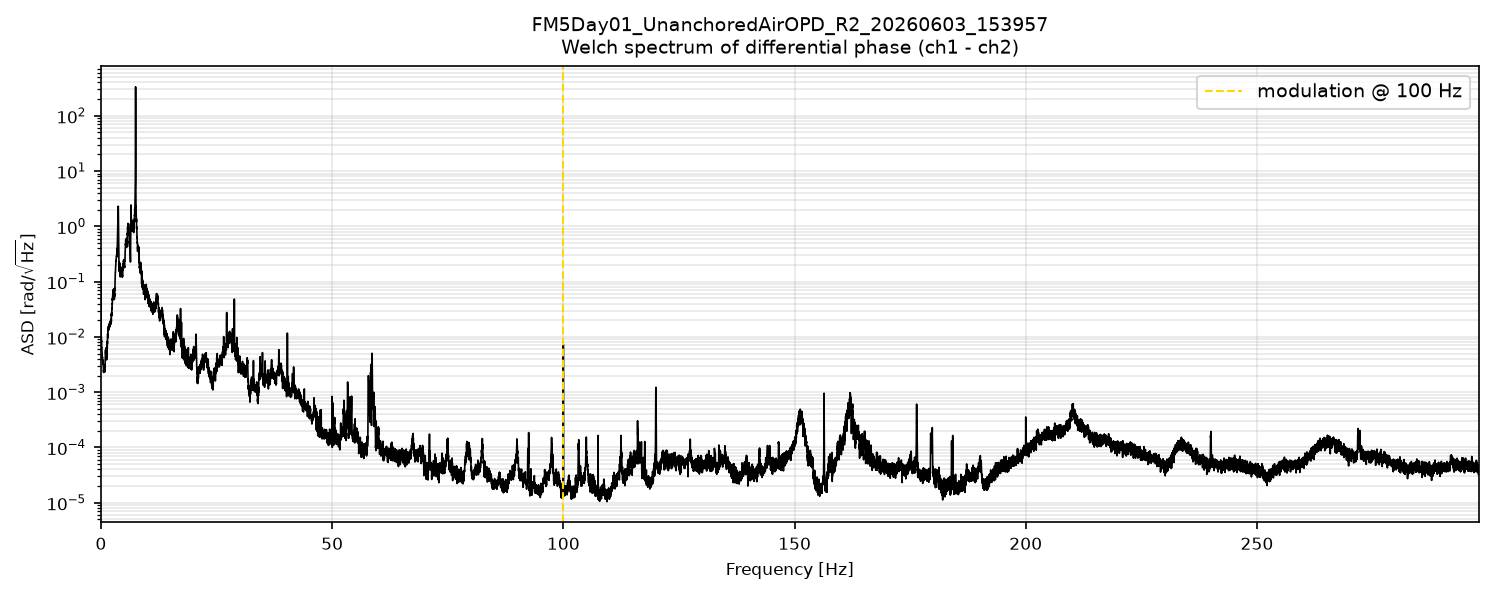

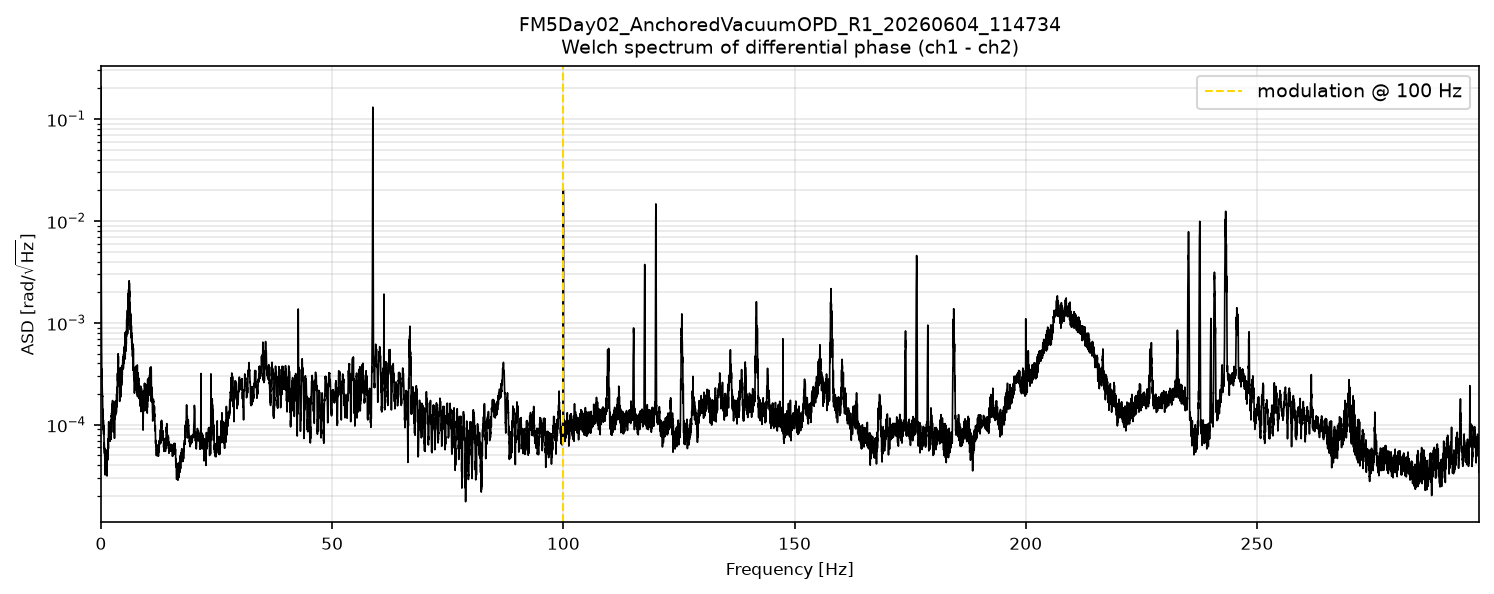

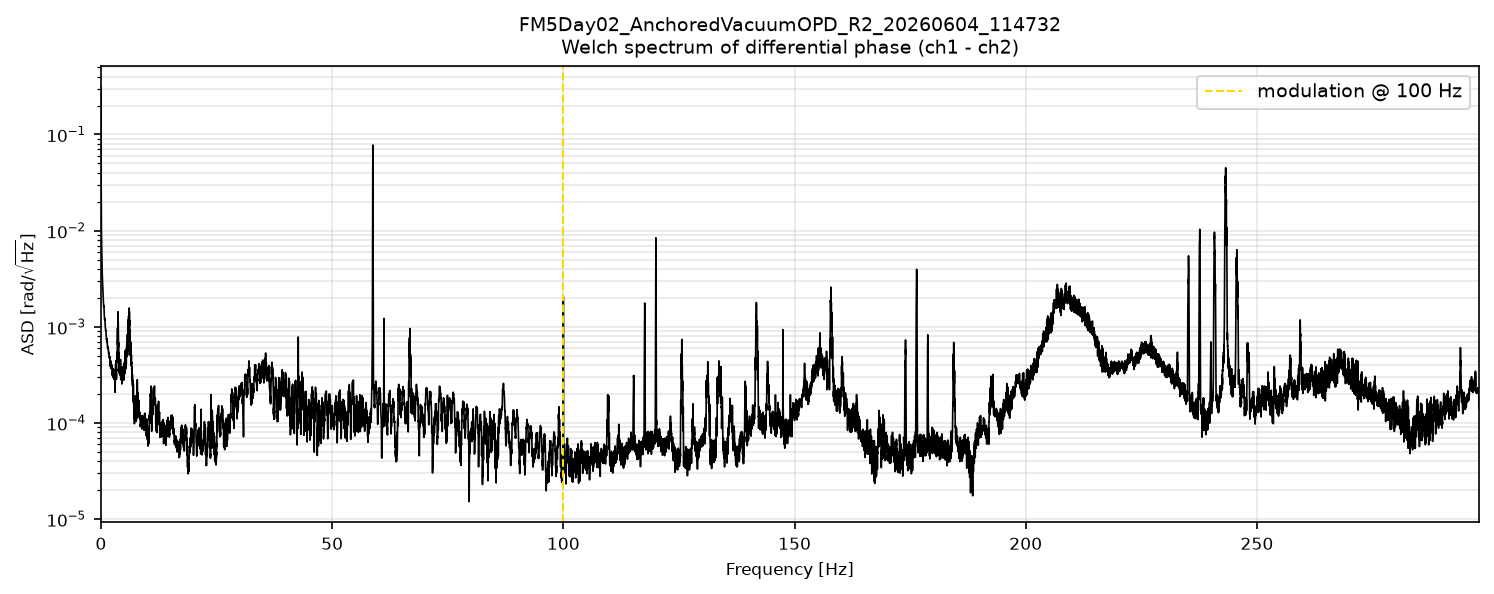

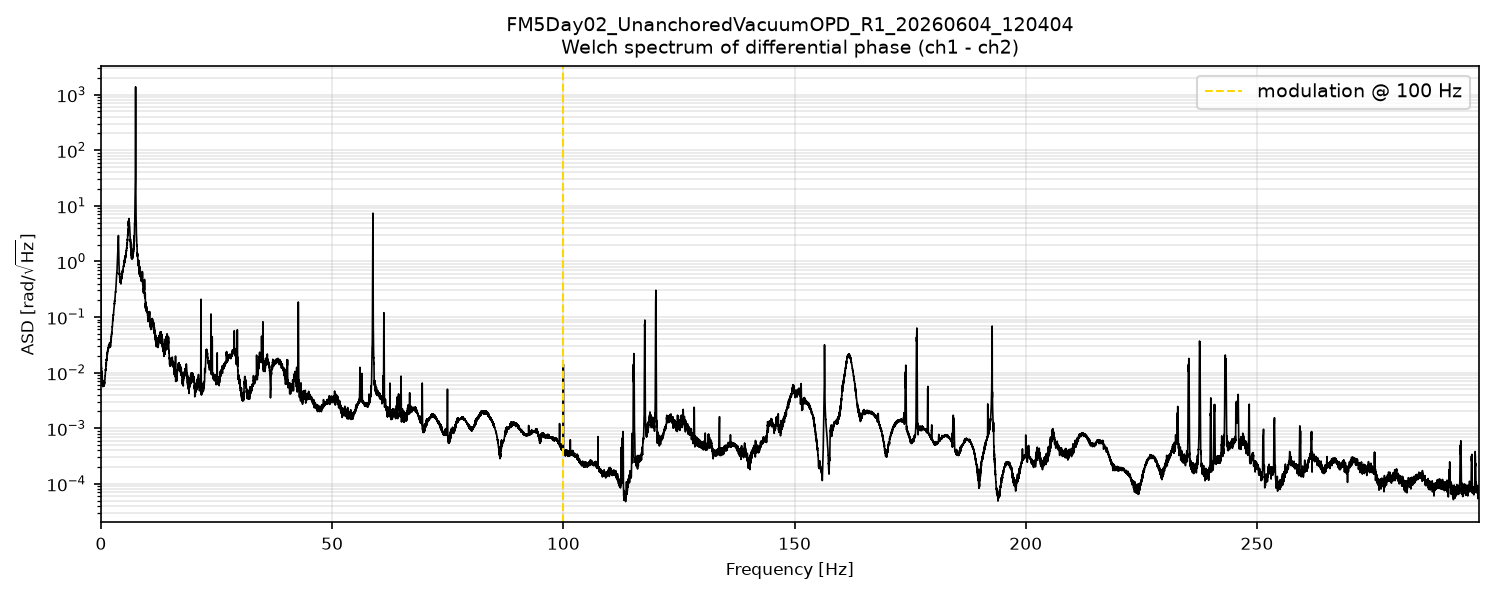

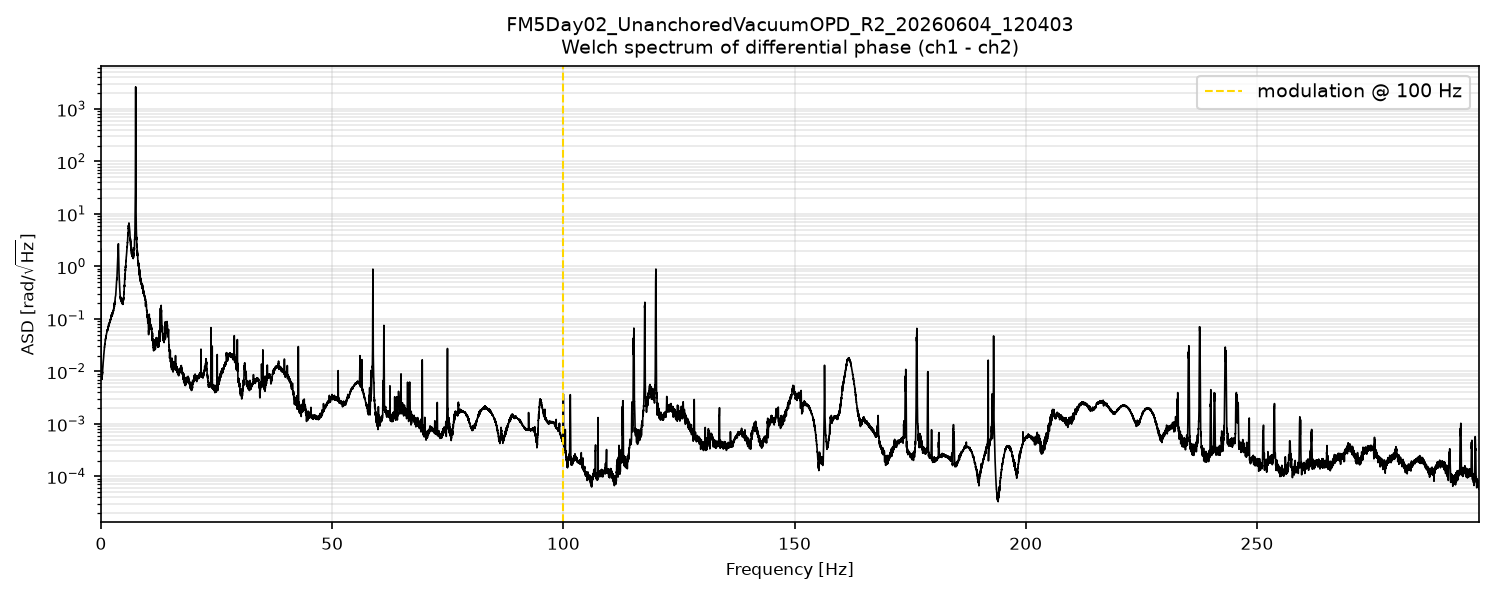

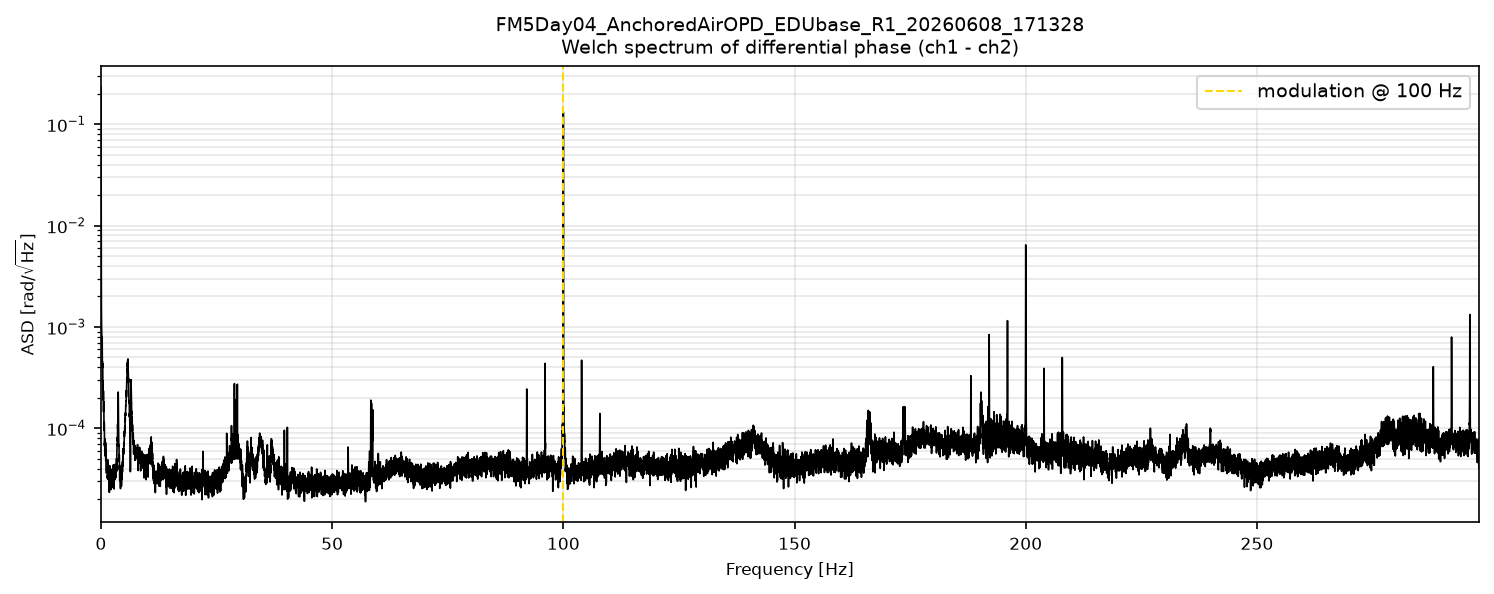

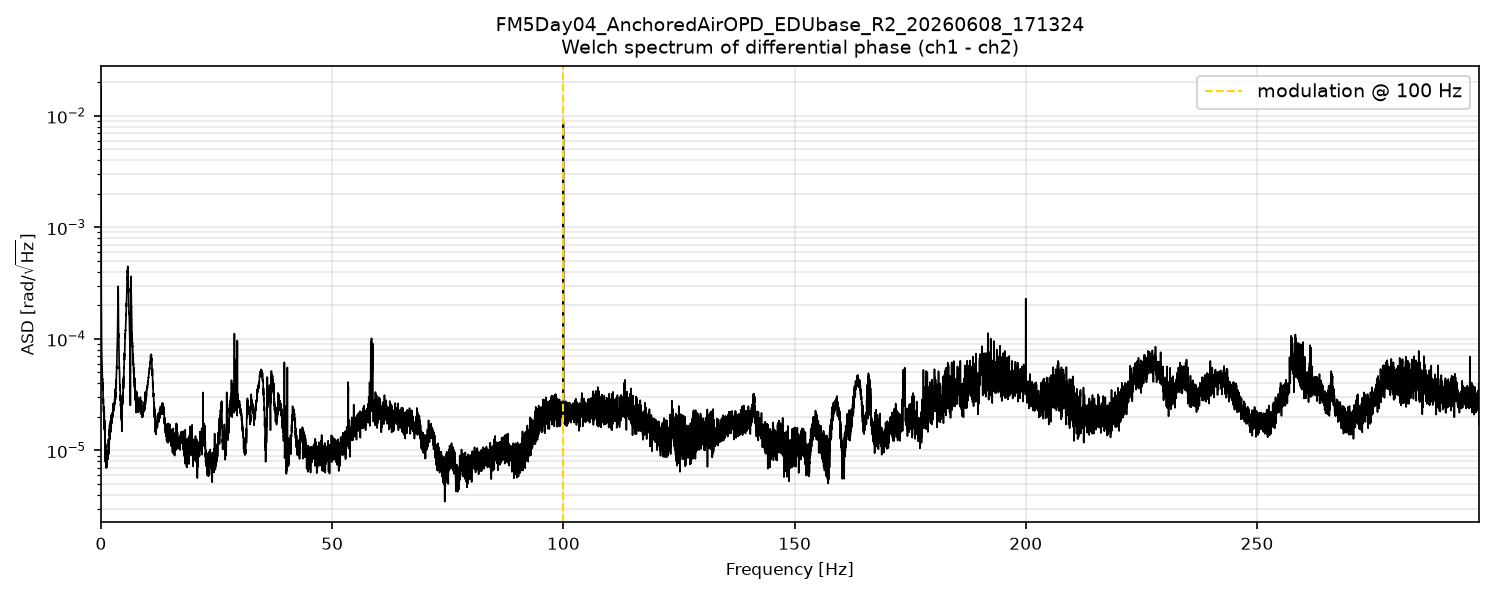

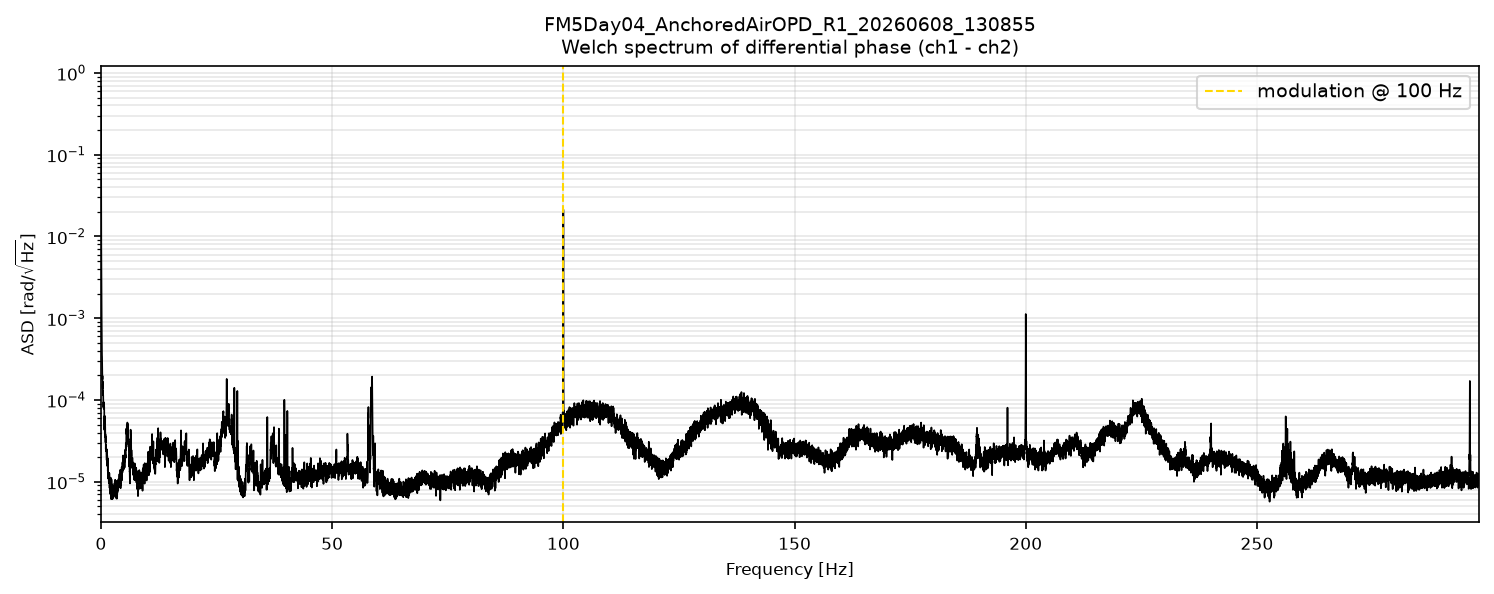

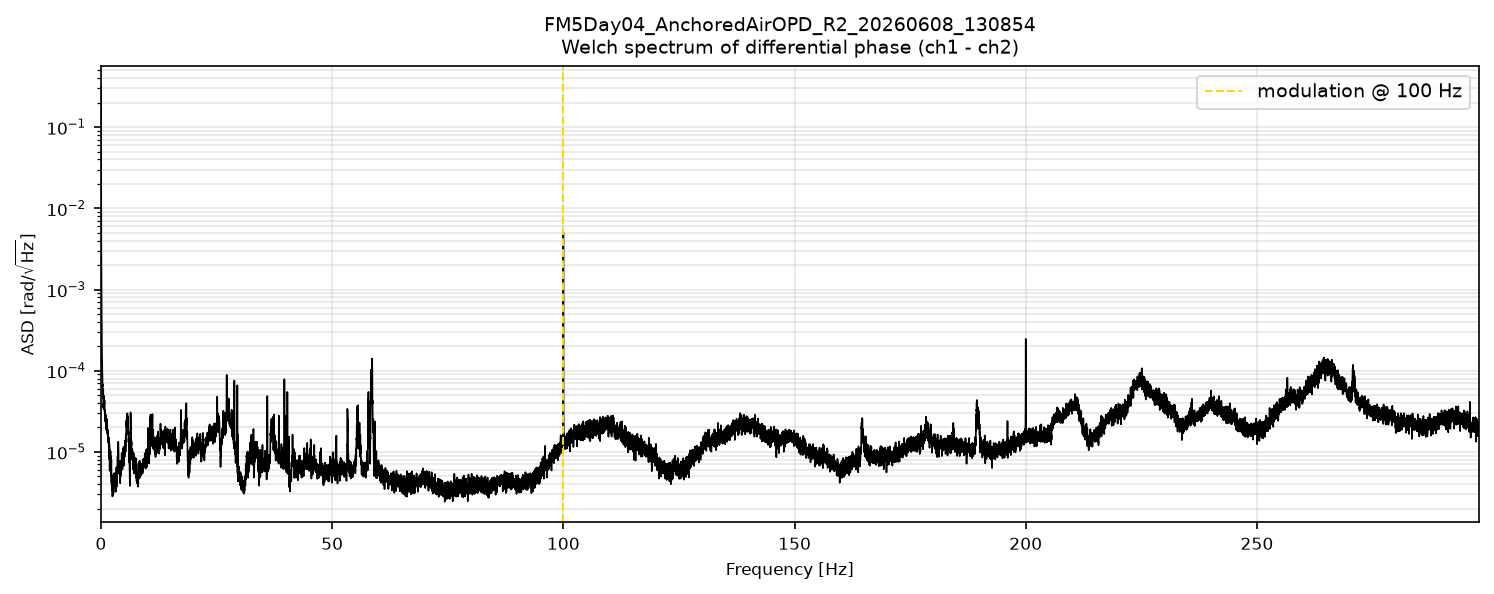

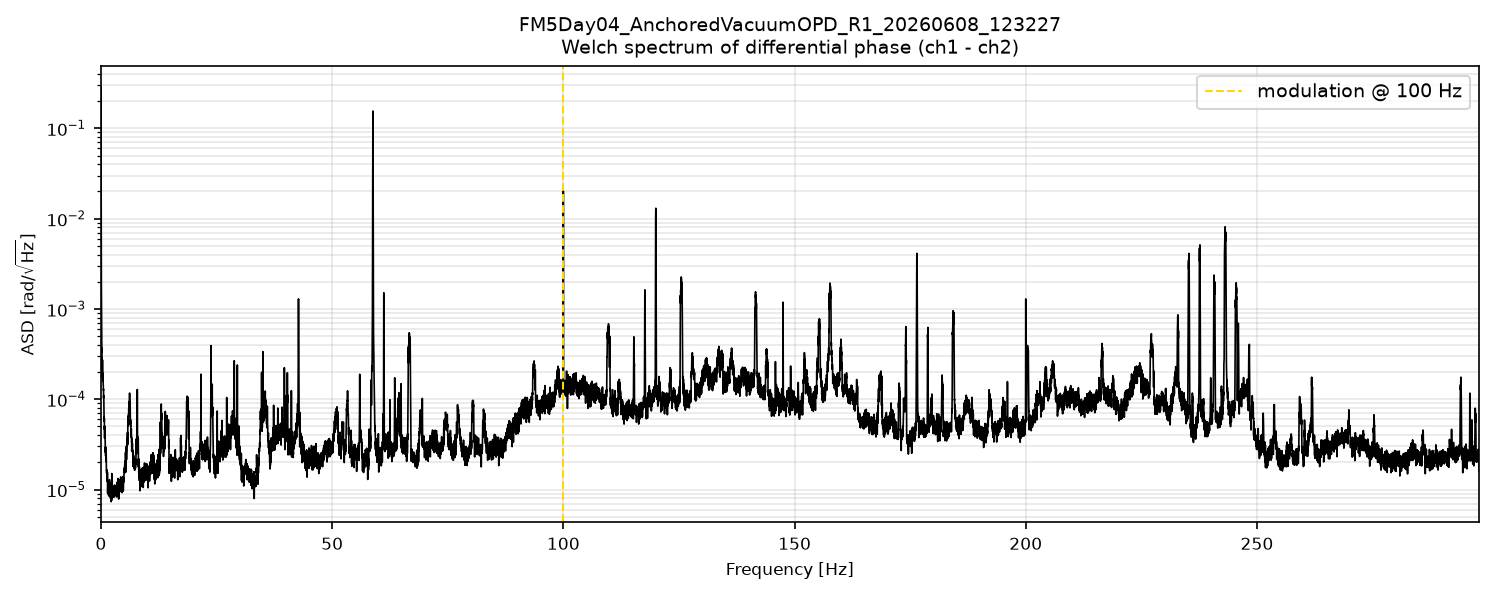

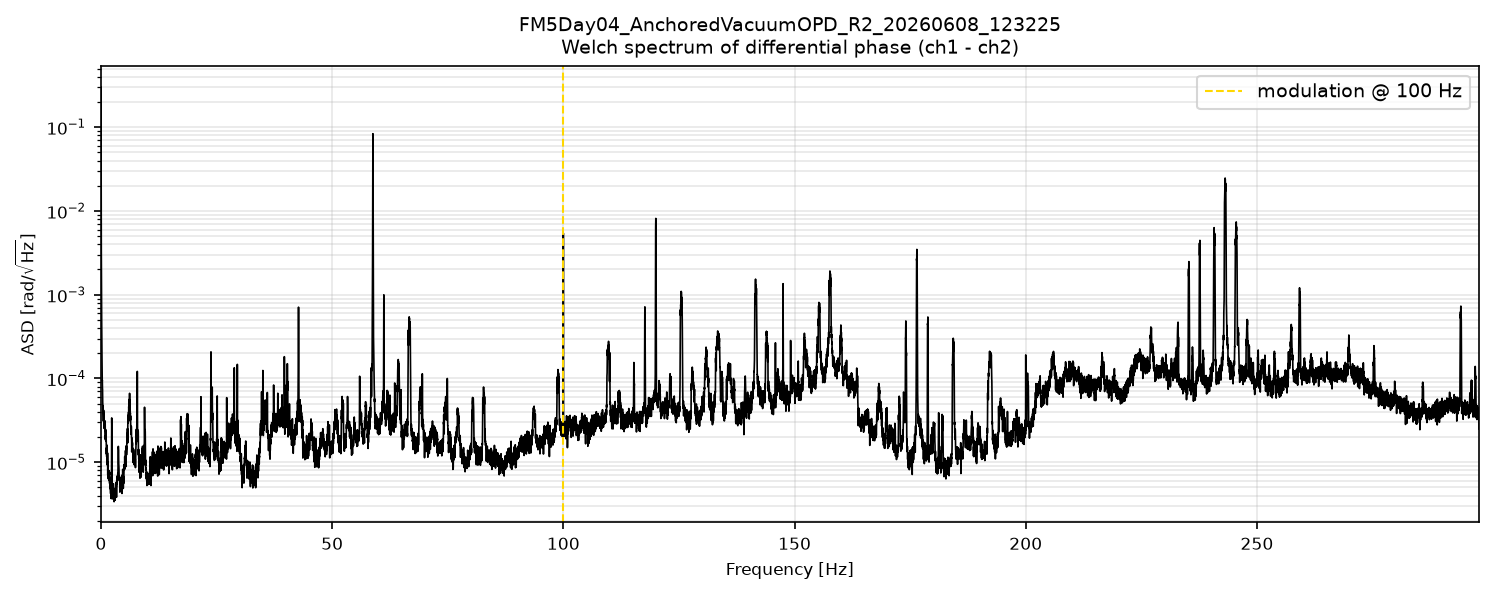

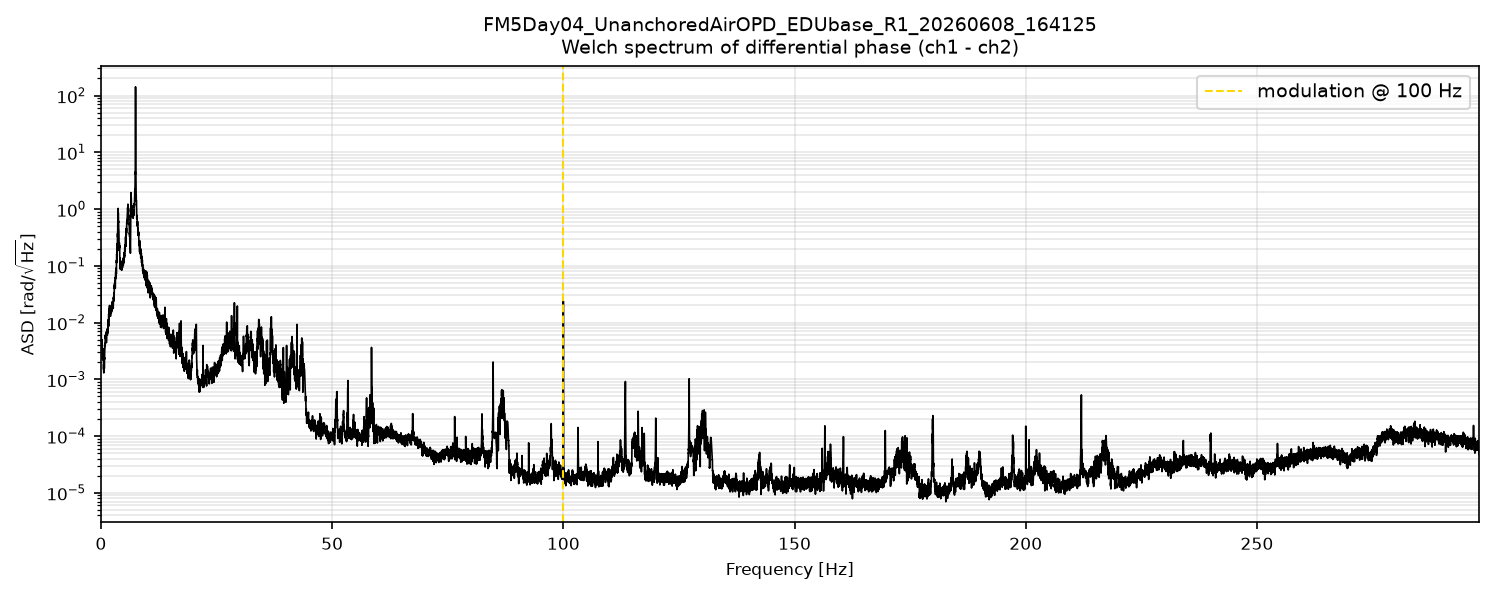

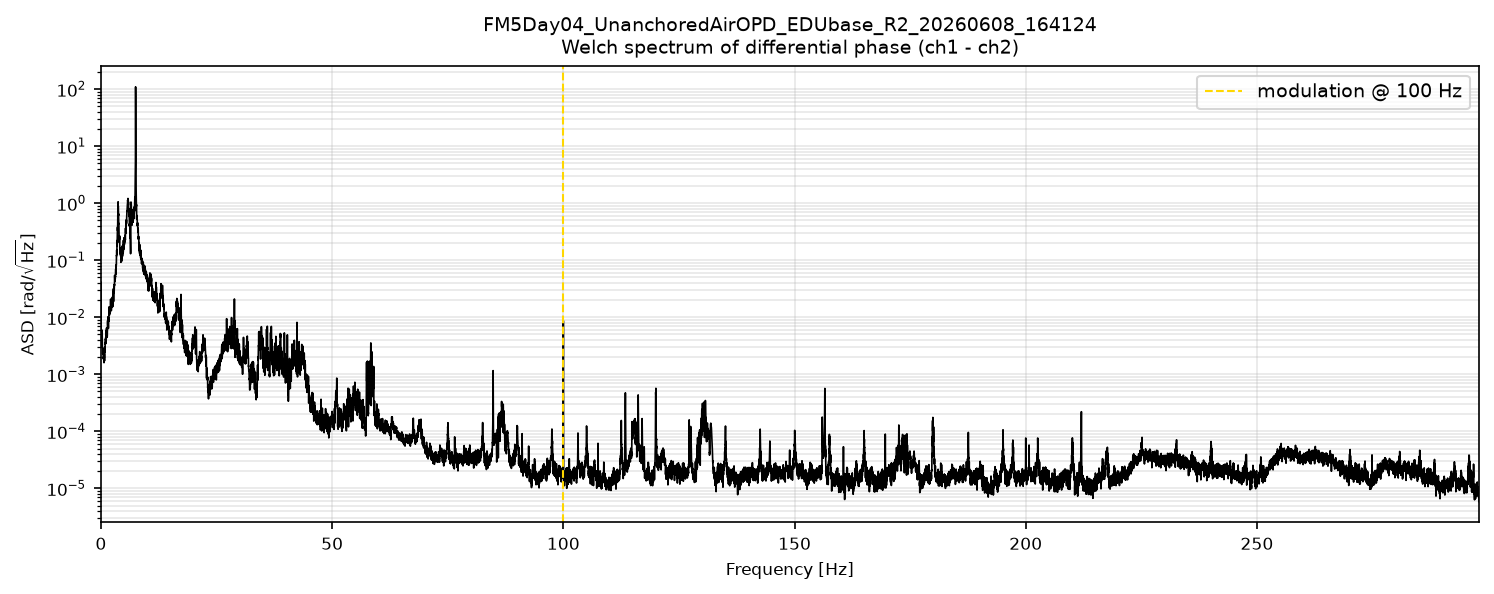

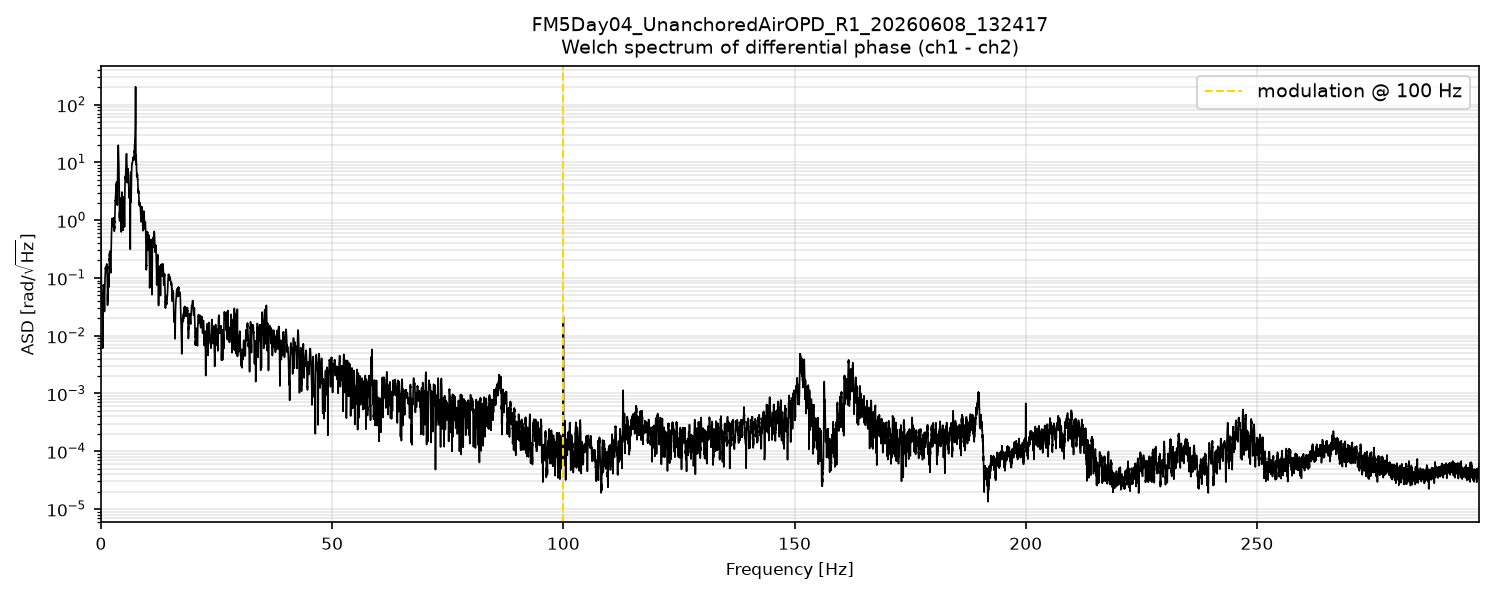

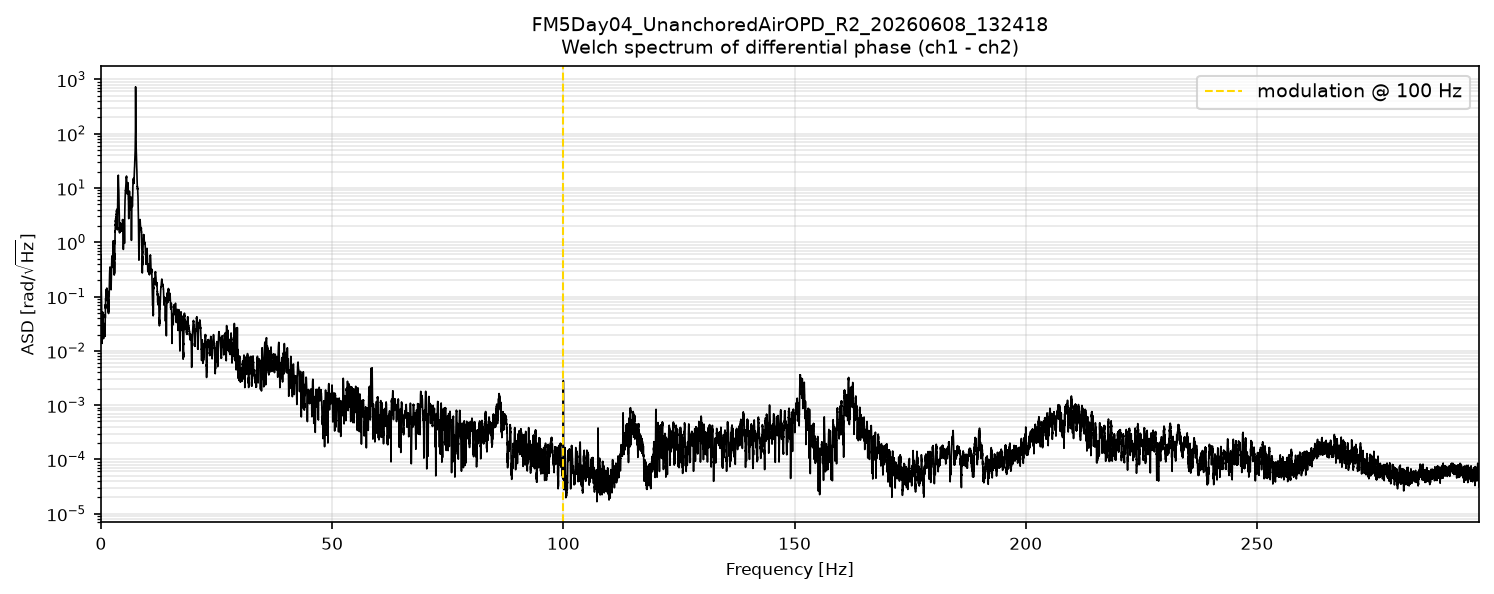

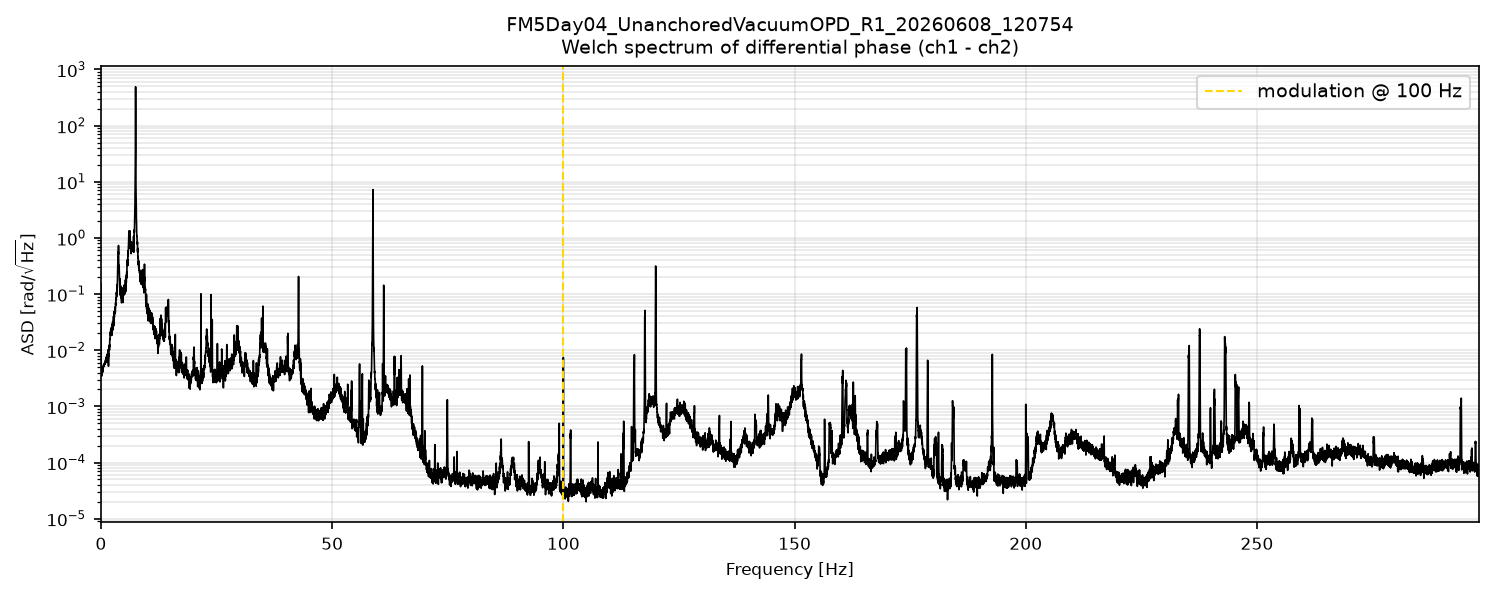

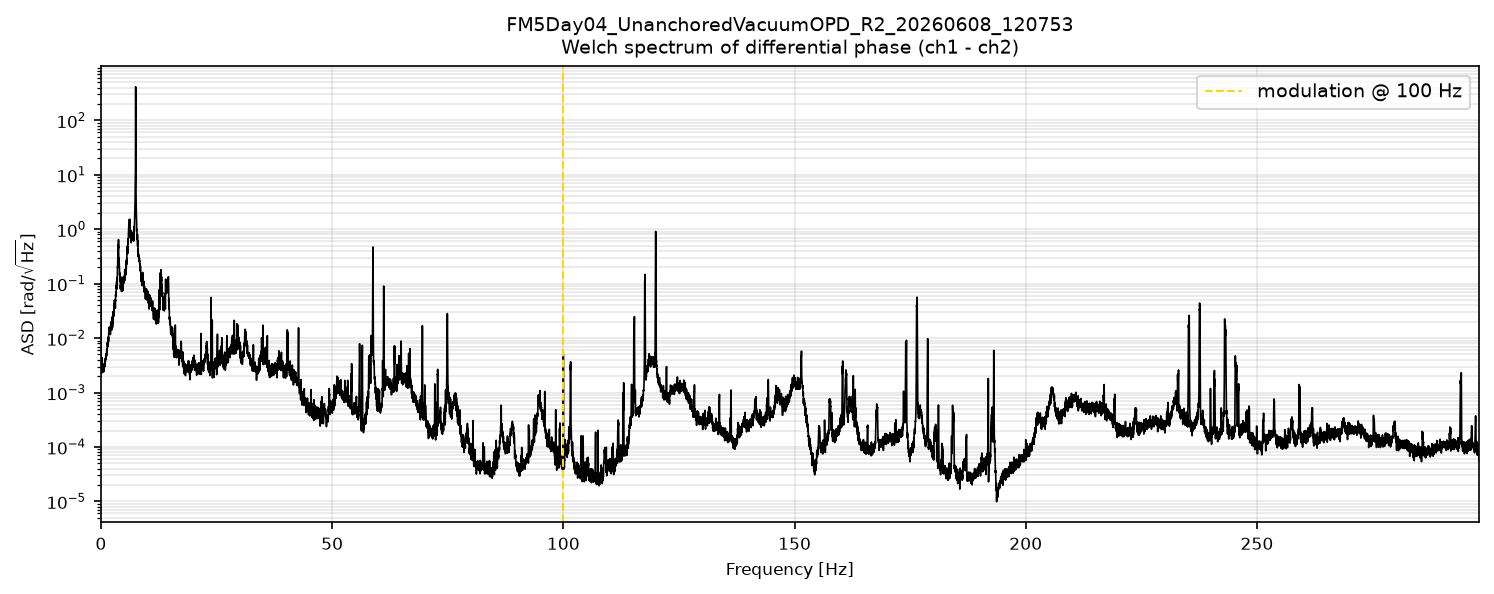

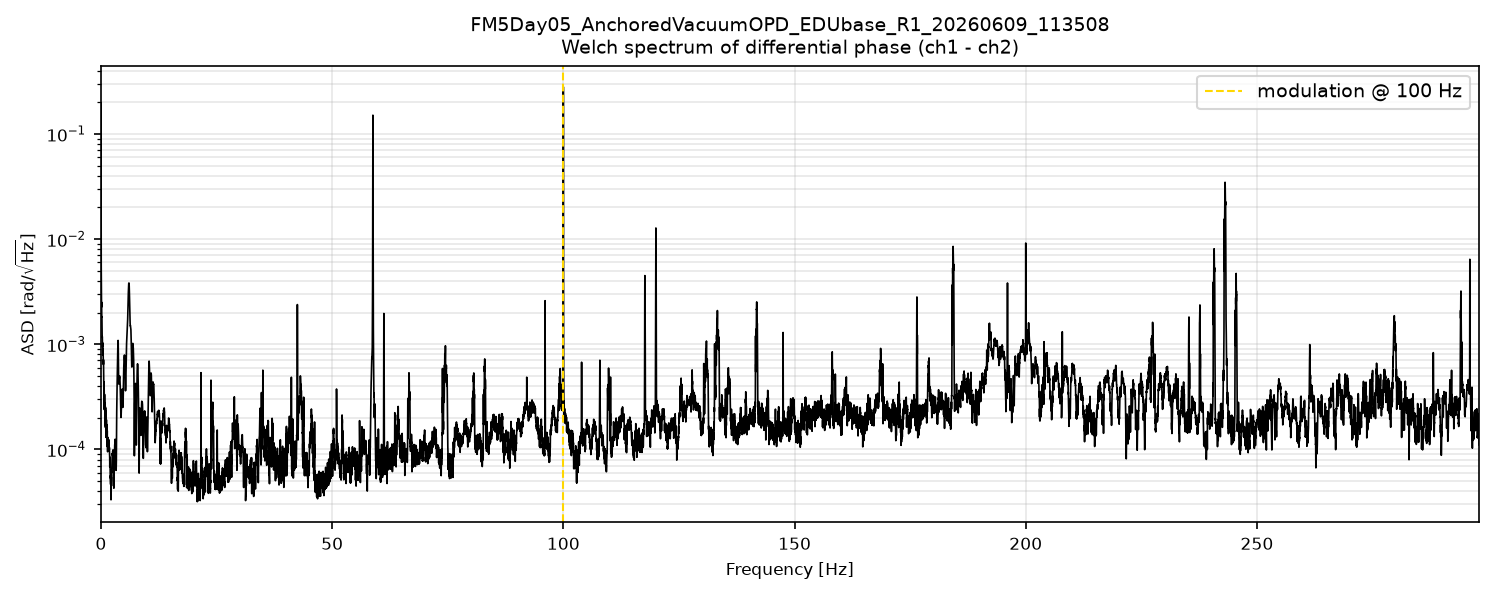

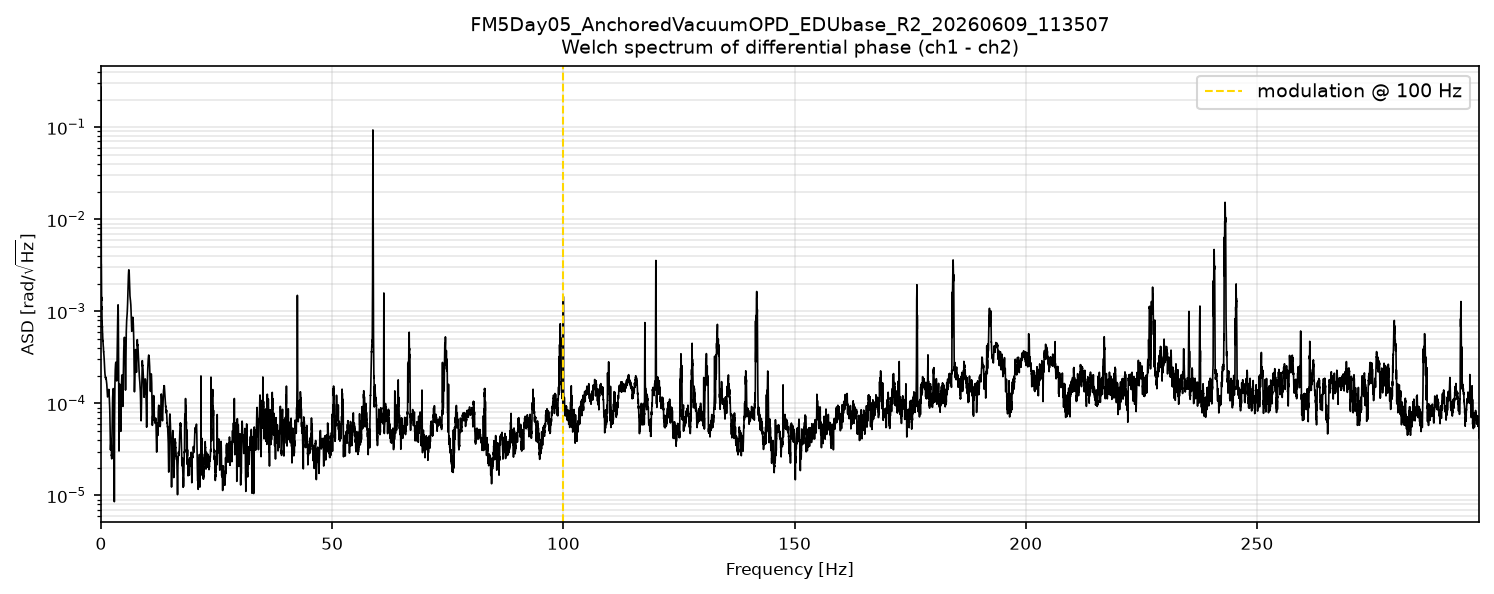

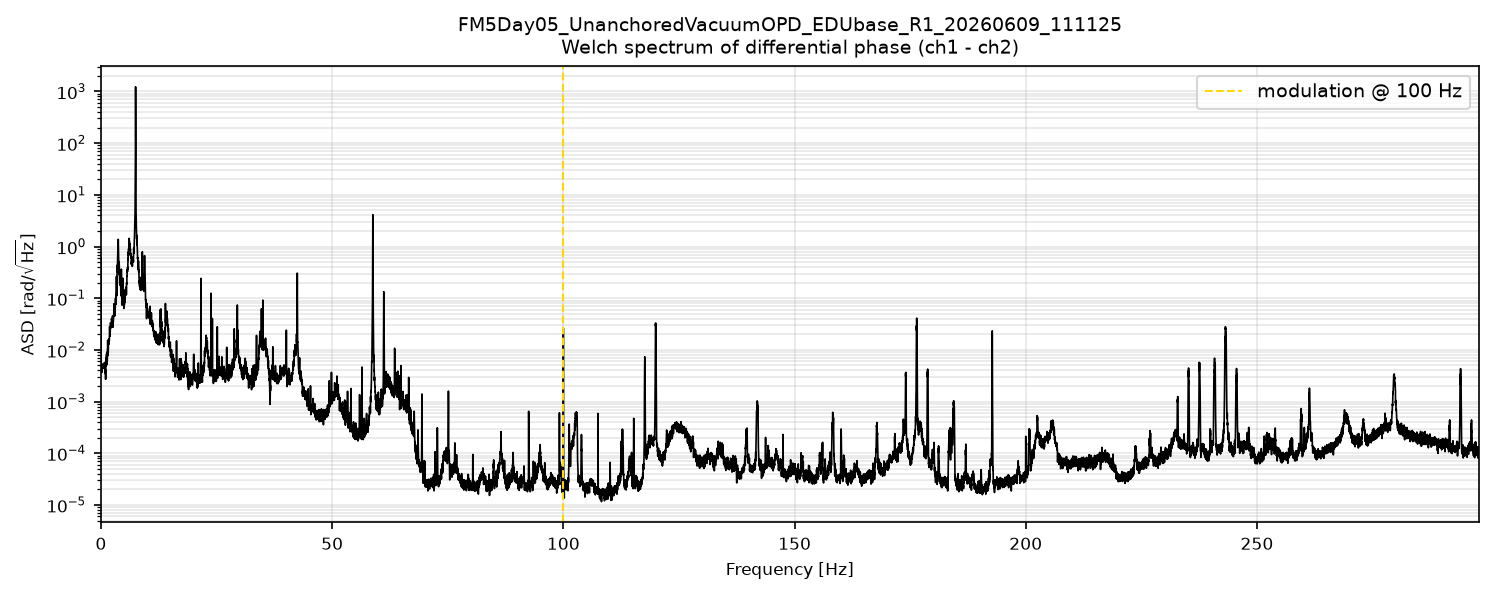

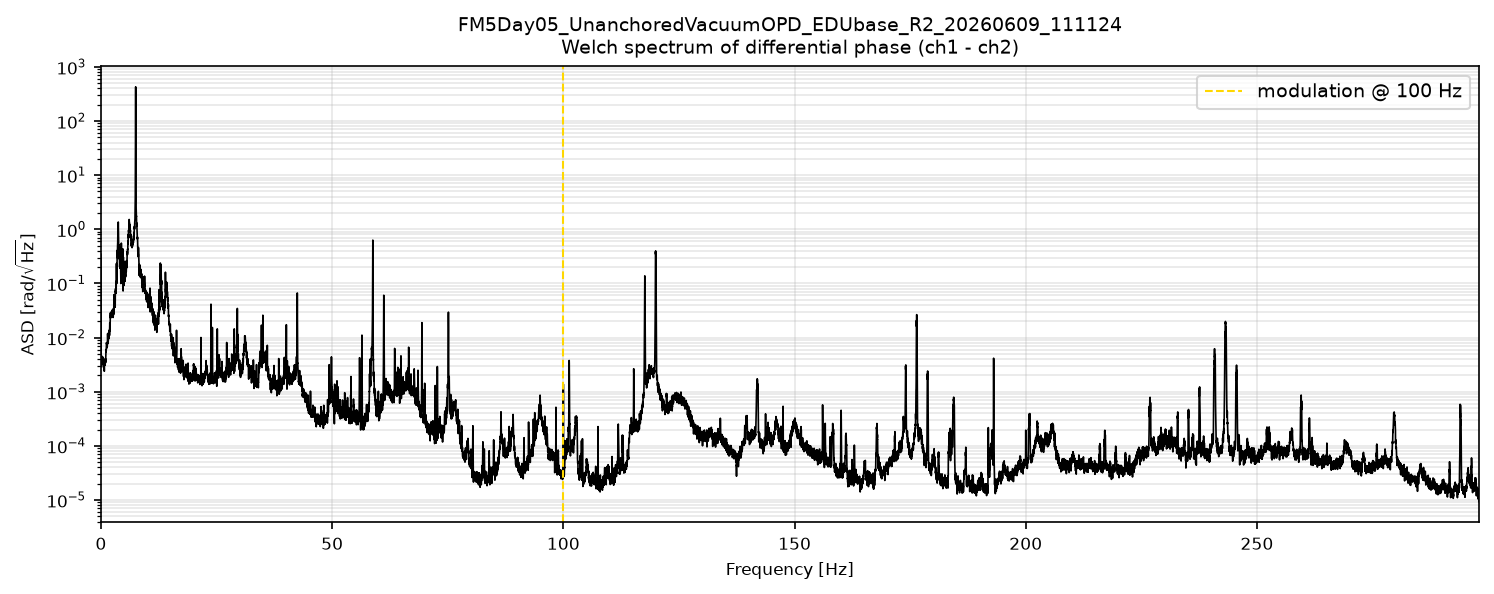

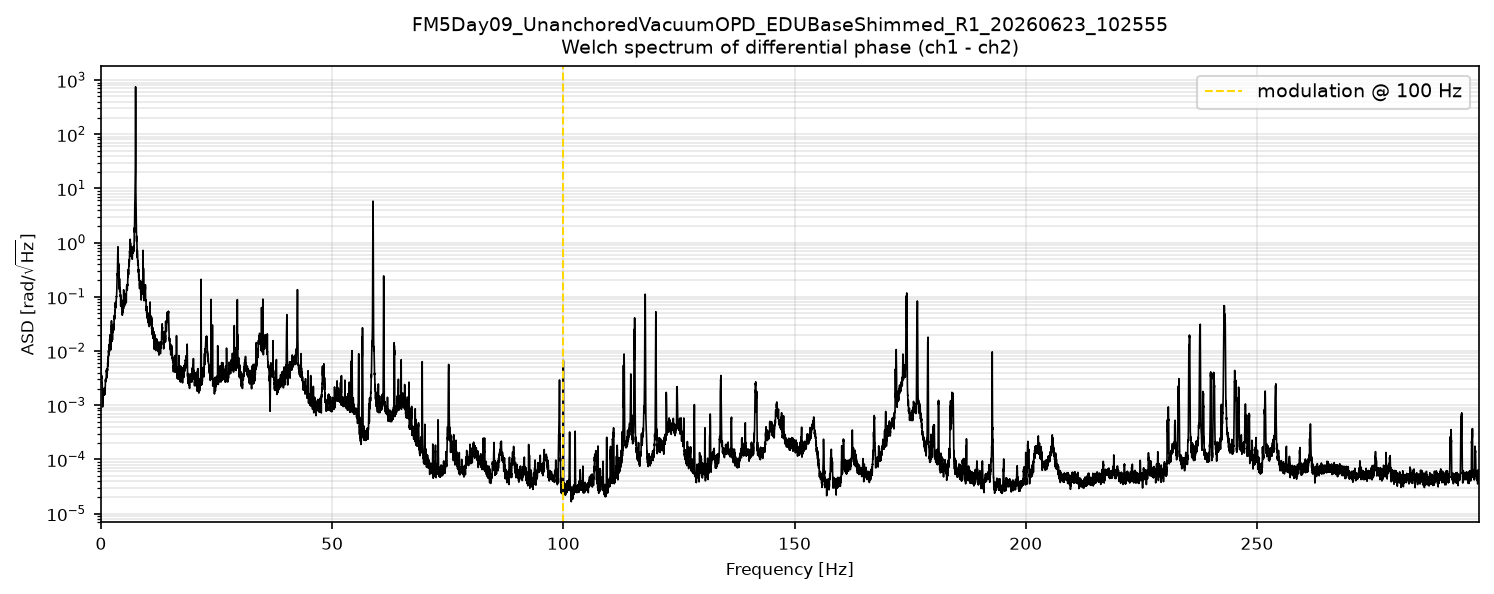

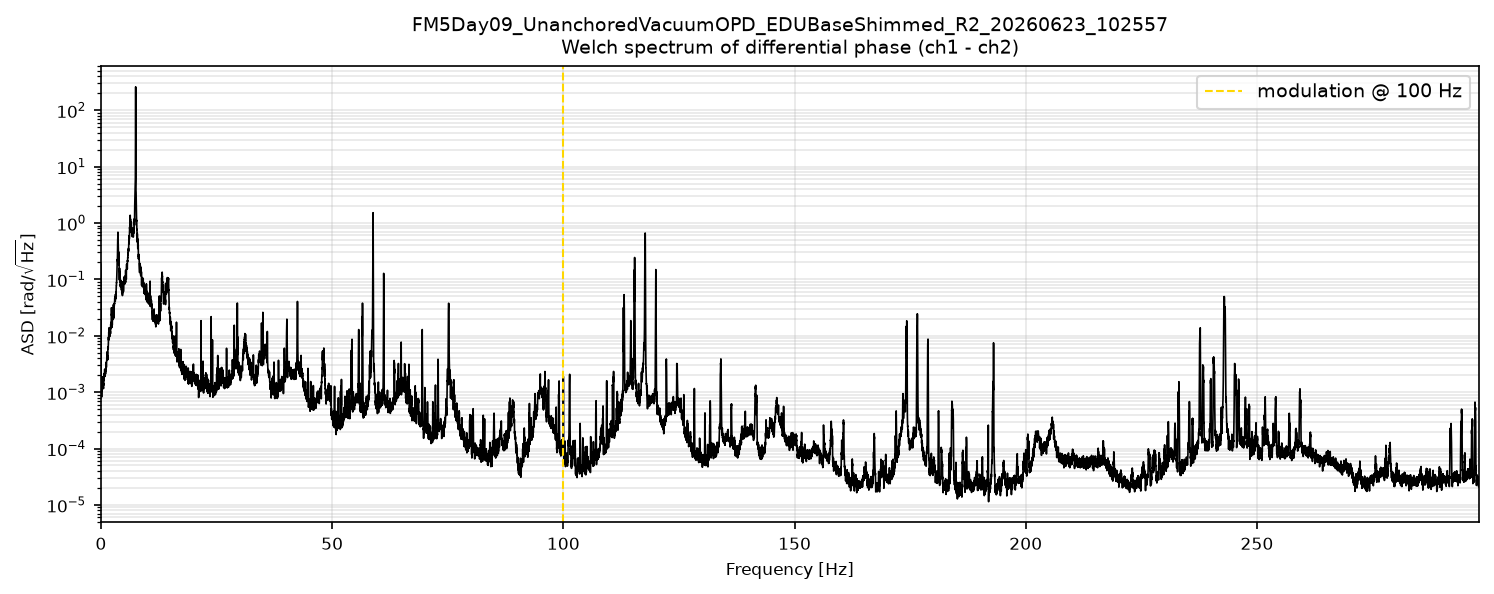

In [3]:
# One separate figure per file. Linear frequency axis (log magnitude so the
# tone and the broadband noise are both visible).
for path in files:
    name = os.path.splitext(os.path.basename(path))[0]
    obj = MokuPhasemeterObject(path)
    phi, label = differential_phase(obj)
    f, asd = welch_asd(phi, obj.fs)

    fmax = FMAX if FMAX is not None else obj.fs / 2
    m = f <= fmax

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(f[m], asd[m], lw=0.8)          # linear frequency axis (x), log ASD (y)

    ax.axvline(MOD_FREQ, color="C3", ls="--", lw=1,
               label=f"modulation @ {MOD_FREQ:g} Hz")
    ax.legend(fontsize=9)

    ax.set_xlim(0, fmax)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"ASD [rad/$\sqrt{\mathrm{Hz}}$]")
    ax.set_title(f"{name}\nWelch spectrum of differential phase ({label})", fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
